# Sentinel — Network Anomaly Detection
## Multi-Class Model Training Notebook
Trains a Random Forest on NSL-KDD dataset for 5-class attack classification.

In [1]:
# Install dependencies if needed
!pip install pandas numpy scikit-learn matplotlib seaborn

  Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl (9.7 MB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ------ --------------------------------- 2.1/12.3 MB 10.9 MB/s eta 0:00:01
   ------------- -

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)
from sklearn.model_selection import train_test_split

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Load NSL-KDD Dataset

In [7]:
# NSL-KDD column names
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

# Load train and test data
train_df = pd.read_csv("data/KDDTrain+.txt", names=columns, header=None, sep='\t')
test_df  = pd.read_csv("data/KDDTest+.txt",  names=columns, header=None, sep='\t')

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
print("\nLabel distribution (train):")
print(train_df["label"].value_counts())

Train shape: (125973, 43)
Test shape:  (22544, 43)

Label distribution (train):
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


## 3. Map Attack Labels to 5 Categories

In [8]:
# NSL-KDD attack category mapping
attack_map = {
    "normal": "Normal",
    # DoS attacks
    "neptune": "DoS", "back": "DoS", "land": "DoS", "pod": "DoS",
    "smurf": "DoS", "teardrop": "DoS", "mailbomb": "DoS",
    "apache2": "DoS", "processtable": "DoS", "udpstorm": "DoS",
    # Probe attacks
    "ipsweep": "Probe", "nmap": "Probe", "portsweep": "Probe",
    "satan": "Probe", "mscan": "Probe", "saint": "Probe",
    # R2L attacks
    "ftp_write": "R2L", "guess_passwd": "R2L", "imap": "R2L",
    "multihop": "R2L", "phf": "R2L", "spy": "R2L",
    "warezclient": "R2L", "warezmaster": "R2L", "sendmail": "R2L",
    "named": "R2L", "snmpgetattack": "R2L", "snmpguess": "R2L",
    "xlock": "R2L", "xsnoop": "R2L", "httptunnel": "R2L",
    # U2R attacks
    "buffer_overflow": "U2R", "loadmodule": "U2R", "perl": "U2R",
    "rootkit": "U2R", "ps": "U2R", "sqlattack": "U2R",
    "xterm": "U2R", "worm": "U2R"
}

train_df["attack_category"] = train_df["label"].map(attack_map).fillna("DoS")
test_df["attack_category"]  = test_df["label"].map(attack_map).fillna("DoS")

print("Category distribution (train):")
print(train_df["attack_category"].value_counts())

Category distribution (train):
attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


## 4. Preprocess — Encode Categorical Features

In [9]:
feature_cols = [c for c in columns[:-2]]  # drop label + difficulty
categorical_cols = ["protocol_type", "service", "flag"]

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])
    encoders[col] = le

X_train = train_df[feature_cols]
y_train = train_df["attack_category"]
X_test  = test_df[feature_cols]
y_test  = test_df["attack_category"]

print("X_train shape:", X_train.shape)
print("Classes:", y_train.unique())

X_train shape: (125973, 41)
Classes: <StringArray>
['Normal', 'DoS', 'R2L', 'Probe', 'U2R']
Length: 5, dtype: str


## 5. Train Multi-Class Random Forest

In [10]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"  # handles class imbalance (U2R is rare)
)

print("Training... this takes 2-3 minutes")
model.fit(X_train, y_train)
print("Training complete!")

Training... this takes 2-3 minutes
Training complete!


## 6. Evaluate Model

In [11]:
y_pred = model.predict(X_test)

print("Test Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 26.85 %

Classification Report:


c:\Users\Shaina Hussain\Sentinel-network-anomaly-detection-using-ML\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shaina Hussain\Sentinel-network-anomaly-detection-using-ML\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

         DoS       1.00      0.27      0.42     22544
      Normal       0.00      0.00      0.00         0
       Probe       0.00      0.00      0.00         0
         R2L       0.00      0.00      0.00         0
         U2R       0.00      0.00      0.00         0

    accuracy                           0.27     22544
   macro avg       0.20      0.05      0.08     22544
weighted avg       1.00      0.27      0.42     22544



c:\Users\Shaina Hussain\Sentinel-network-anomaly-detection-using-ML\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 7. Confusion Matrix

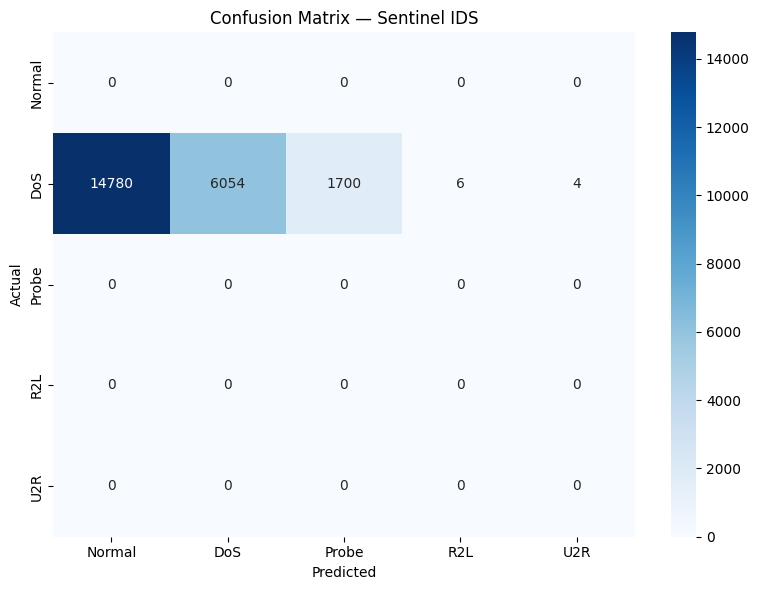

Saved confusion_matrix.png


In [12]:
labels = ["Normal", "DoS", "Probe", "R2L", "U2R"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix — Sentinel IDS")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved confusion_matrix.png")

## 8. Feature Importance

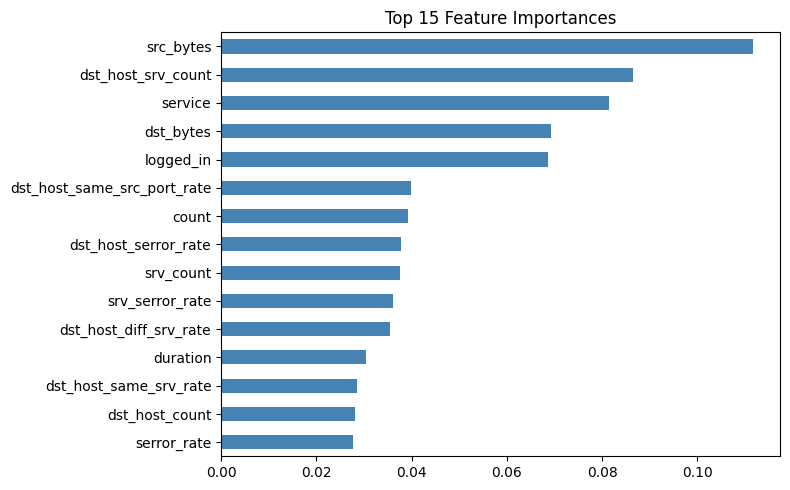

In [13]:
importances = pd.Series(model.feature_importances_, index=feature_cols)
top15 = importances.nlargest(15)

plt.figure(figsize=(8, 5))
top15.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

## 9. Save New Model Files

In [14]:
os.makedirs("../backend/model", exist_ok=True)

with open("../backend/model/best_ids_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("../backend/model/encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

with open("../backend/model/feature_names.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("Model files saved to ../backend/model/")
print("Classes:", list(model.classes_))

Model files saved to ../backend/model/
Classes: ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']
